# Image Blending with Laplacian Pyramids

1. Construct the Laplacian pyramid for each image
2. Construct the Gaussian pyramid for the two mask images
3. Multiply each Laplacian image by its corresponding mask and sum the images 
4. Reconstruct the final image from the blended Laplacian pyramid

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import convolve2d

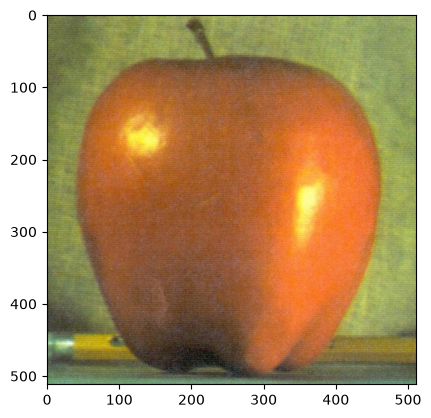

In [ ]:
apple = cv2.imread("data/apple.jpg")
orange = cv2.imread("data/orange.jpg")

# convert to numpy arrays
apple = np.array(cv2.cvtColor(apple, cv2.COLOR_BGR2RGB))
orange = np.array(cv2.cvtColor(orange, cv2.COLOR_BGR2RGB))

plt.imshow(apple)

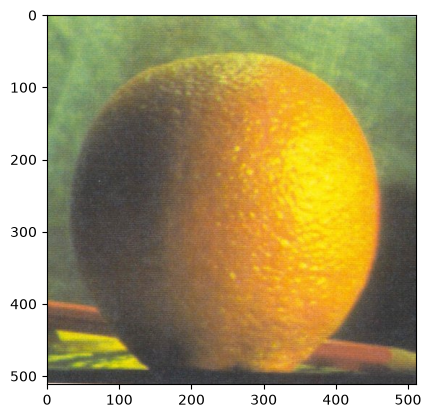

In [3]:
plt.imshow(orange)

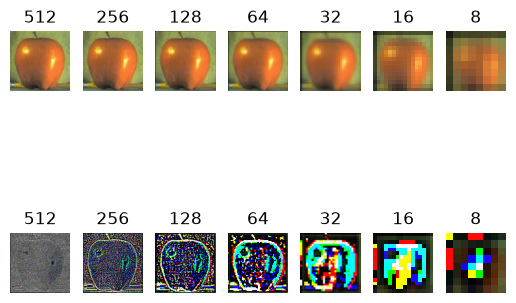

In [4]:
def laplacian_pyramid(image, levels):
    h = 1 / 16 * np.array([1, 4, 6, 4, 1])
    h = h[:, None] * h[None, :]
    gaussian_pyramid = [image]
    laplacian_pyramid = []
    for _ in range(levels):
        # subsample the image
        # NOTE: inefficient, but we want to keep the code simple
        new_image = np.zeros(
            (image.shape[0] // 2, image.shape[1] // 2, 3), dtype=image.dtype
        )
        for c in range(3):
            new_image[:, :, c] = convolve2d(image[:, :, c], h, mode="same")[::2, ::2]
        gaussian_pyramid.append(new_image)
        image = new_image

        # now we need to upsample the image back to the original size
        upsampled = np.zeros_like(gaussian_pyramid[-2])
        upsampled[::2, ::2] = gaussian_pyramid[-1]
        for c in range(3):
            # need gain=4 to compensate for the fact that we are inserting zeros
            upsampled[:, :, c] = convolve2d(upsampled[:, :, c], 4 * h, mode="same")
        laplacian = gaussian_pyramid[-2] - upsampled
        laplacian_pyramid.append(laplacian)
    return gaussian_pyramid, laplacian_pyramid


LEVELS = 7
G, L = laplacian_pyramid(apple, LEVELS)

for i in range(LEVELS):
    plt.subplot(2, LEVELS, i + 1)
    plt.imshow(G[i])
    plt.title(G[i].shape[0])
    plt.axis("off")
    plt.subplot(2, LEVELS, i + 1 + LEVELS)
    plt.imshow(L[i])
    plt.title(L[i].shape[0])
    plt.axis("off")

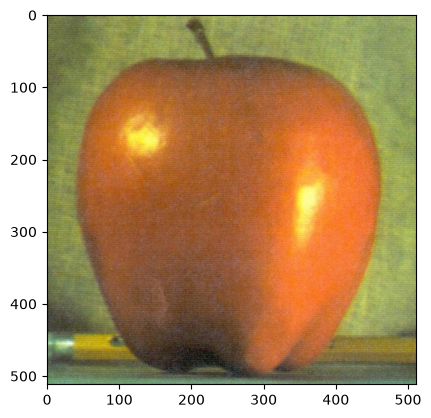

In [5]:
def img_from_pyramid(G, L):
    h = 1 / 16 * np.array([1, 4, 6, 4, 1])
    h = h[:, None] * h[None, :]

    reco = G[-1]
    for i in range(len(L) - 1, -1, -1):
        upsampled = np.zeros_like(G[i])
        upsampled[::2, ::2] = reco
        for c in range(3):
            upsampled[:, :, c] = convolve2d(upsampled[:, :, c], 4 * h, mode="same")
        reco = upsampled + L[i]
    return reco


reconstructed = img_from_pyramid(G, L)
plt.imshow(reconstructed)

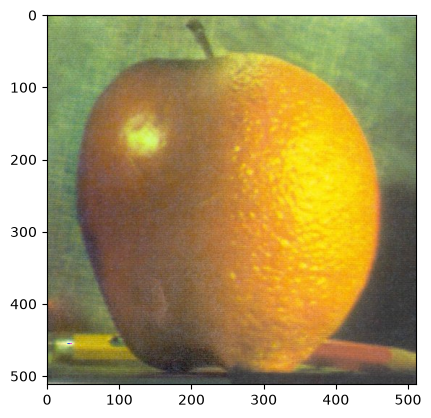

In [6]:
def blend(G1, L1, G2, L2, mask):
    Gm, _ = laplacian_pyramid(mask, LEVELS)

    Gblend, Lblend = [], []
    for L in range(len(G1)):
        Gblend.append(G1[L] * Gm[L] + G2[L] * (1 - Gm[L]))
        if L < len(L1):
            Lblend.append(L1[L] * Gm[L] + L2[L] * (1 - Gm[L]))

    # blend and reconstruct
    blended = img_from_pyramid(Gblend, Lblend)
    return blended


Ga, La = laplacian_pyramid(apple, LEVELS)
Go, Lo = laplacian_pyramid(orange, LEVELS)

mask = np.zeros_like(apple)
mask[:, : mask.shape[1] // 2, :] = 1

blended = blend(Ga, La, Go, Lo, mask)
plt.imshow(blended)

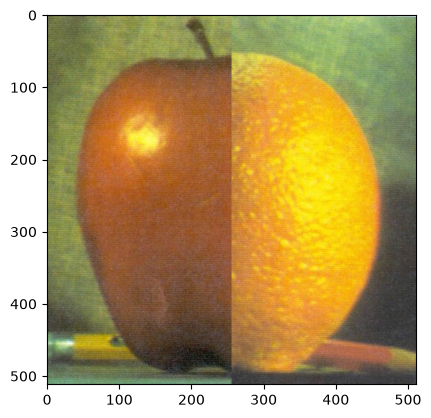

In [7]:
mask = np.zeros_like(apple)
mask[:, : mask.shape[1] // 2, :] = apple[:, : mask.shape[1] // 2, :]
mask[:, mask.shape[1] // 2 :, :] = orange[:, mask.shape[1] // 2 :, :]
plt.imshow(mask)